# Ideals 
- what if we apply SIGReg to GPT-2 ? 
- what if we try the linear output (1:2:1) (1:1:1) (1:0.5:1)
- what about scaled dot product attention (what we can change here)
- what if we remove layerNorm 
- RMSNorm

# Build GPT 
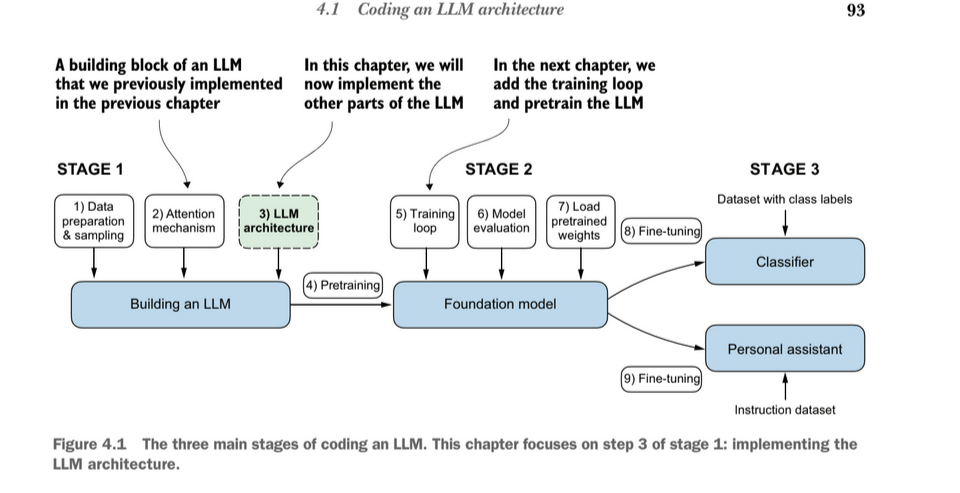

In [68]:

import tiktoken 

tokenizer = tiktoken.get_encoding("gpt2")

GPT_CONFIG_124M = {
    "vocab_size":  tokenizer.n_vocab, # size of vocab
    "context_length": 256, # sequence length of each sample x
    "emb_dim": 768, # number of dimension of each vector(represent for a token) 
    "n_heads": 12, # number of heads in multihead attention
    "n_layers": 12, # number of layers 
    "dropout_rate": 0.5, # dropout rate 
    "qkv_bias": False, # Query, Key, Value Linear bias 
    "FNN_scale": 4,
}



In [69]:
import torch
import torch.nn as nn 




# a placeholder for GPT model architecture class 
class DummyGPTModel(nn.Module): 
    """
    set up configuration for building blocks: 
    - token embedding 
    - positional embedding
     -> transformer block 
     - MHA
     - activation 
     - layerNorm 
     - residual connection 
     - Fully connected layer 
    """
    def __init__(self, cfg): 
        
        super().__init__()
        # embedding token
        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"]) 
        self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.dropout_embedding = nn.Dropout(cfg["dropout_rate"])
        
        # transformer block 
        # self.transformer_blocks = nn.ModuleList(
        #     DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])
        # )
        # the use of ModuleList allow us to customize the input parameter of each module in the list
        # we must do this manually because this is just a list of module

        self.transformer_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])] # unpack the list to item inside, because Sequential require each module input, not a list
        )
        # sequential auto call forward function of each module it a recurrent block3(block2(block1)) ... 

        self.final_norm = DummyLayerNorm(cfg)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
        # TODO: out head here is just like classification right? so LLM is Classification right ?, WHY bias FALSE
    
    def forward(self, in_idx): 
        batch_size, seq_len = in_idx.shape

        # embed 
        token_embed = self.token_embedding(in_idx)  # (batch, seq_len, emb_dim) embedding just like create one hot but way more efficiency
        pos_embed = self.pos_embedding(
            torch.arange(seq_len, device=in_idx.device)
        ) # (batch, seq_len, embed_dim)

        x = token_embed + pos_embed
        x = self.dropout_embedding(x)  # TODO: why dropout after embedding


        # transformer 
        x = self.transformer_blocks(x)
        
        
        # post 
        x = self.final_norm(x)
        logits = self.out_head(x)
        print(logits.shape)
        return logits
        
        



class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        
        
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.scale = nn.Parameter(torch.zeros(cfg["emb_dim"]))
        self.shift = nn.Parameter(torch.ones(cfg["emb_dim"]))
        self.epsilon = 1e-9
        
        
    def forward(self, x): 
        # x (batch, ..., emb_dim)
        # norm 
        mean = torch.mean(x, dim=-1, keepdim=True)
        var = torch.var(x, dim=-1, correction=0, keepdim=True) # no bassel correction 
        
        x_norm = (x - mean) / torch.sqrt(var + self.epsilon)

        # let it can scale and shift 
        out = self.scale * x_norm + self.shift 
        return out 

    
    
    
text1 = "Every effort moves you"
text2 = "Every day holds a"
batch = []
batch.append(tokenizer.encode(text1))
batch.append(tokenizer.encode(text2))

# print(batch)
batch = torch.tensor(batch)
print(batch)



torch.manual_seed(123)
gpt = DummyGPTModel(GPT_CONFIG_124M)
logits = gpt.forward(batch)


tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4, 50257])


In [70]:
# layernorm 
torch.manual_seed(123)
x = torch.randn((2,5))
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU(inplace=False))
out = layer(x)
print(out)

mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)


print(mean)
print(var)

out_layer_norm = (out - mean)/ (var**0.5)
print(out_layer_norm)
print(out_layer_norm.mean(dim=-1))
print(out_layer_norm.var(dim=-1))

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
tensor([9.9341e-09, 1.9868e-08], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000], grad_fn=<VarBackward0>)


# LayerNorm 
- chi tiết sẽ được viết trong 1 cái note sẽ được gắn link ở dưới: 


# Implement GELU, FeedForward, Residual Connection

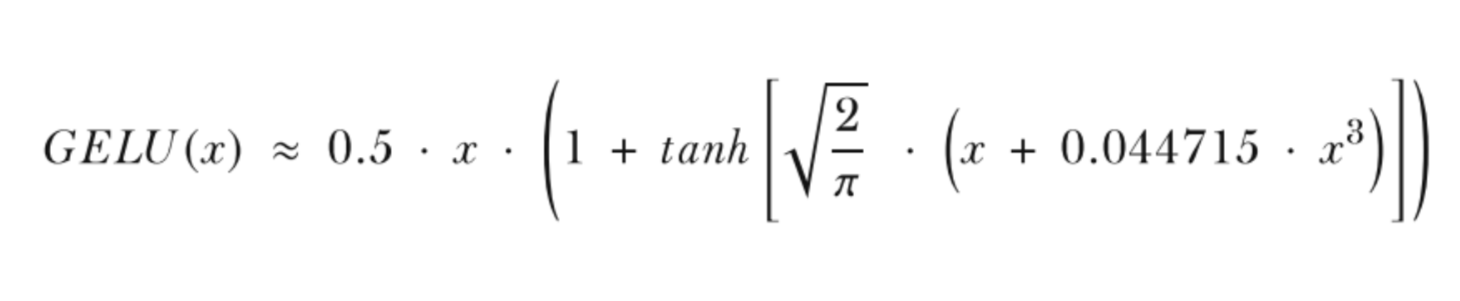

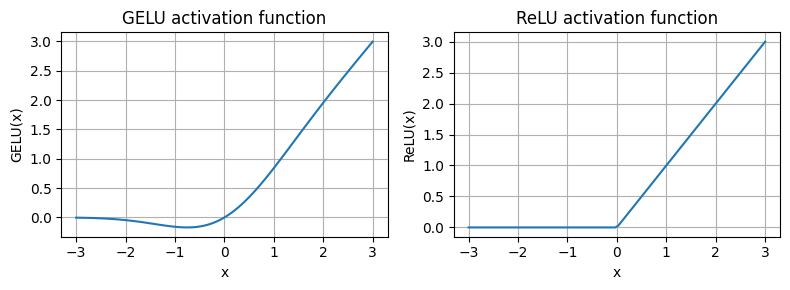

In [71]:
class GELU(nn.Module): 
    def __init__(self): 
        super().__init__()

    def forward(self, x): 
        gelu = 0.5 * x * (1 + torch.tanh((2.0/torch.pi)**0.5 * (x + 0.044715 * x**3)))      
        return gelu

import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
plt.show()
        
        
    

In [72]:
class FeedForward(nn.Module): 
    def __init__(self, cfg): 
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], cfg["FNN_scale"] * cfg["emb_dim"]),
            GELU(),
            nn.Linear(cfg["FNN_scale"] * cfg["emb_dim"], cfg["emb_dim"] ),
        )

    def forward(self, x): 
        return self.layers(x)

        
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])
